In [1]:
import pandas as pd

df = pd.read_csv("Telco_Customer_Churn.csv")

print(df.head())
print(df.info())
print(df.describe())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [2]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [3]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [4]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [5]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [6]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

# Churn Distribution Analysis

In [9]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

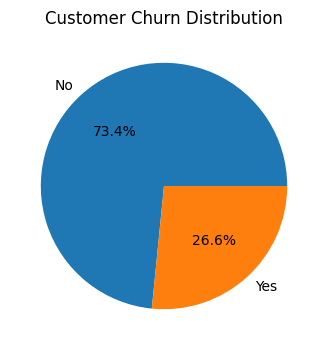

In [15]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%", #autopct -> autopercentage , %1.1f%% -> shows 1 digit after the decimal in percentage
    figsize=(4,4)
)

plt.title("Customer Churn Distribution")
plt.ylabel("")
plt.show()

# Contract Type Analysis

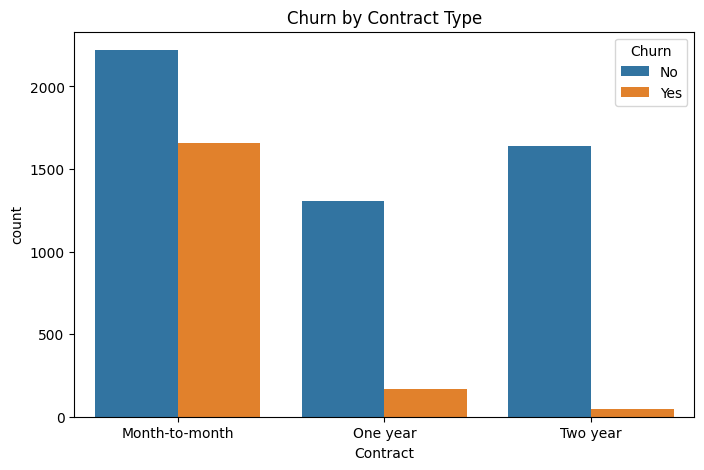

In [17]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Churn by Contract Type")
plt.show()

# INTERNET SERVICE ANALYSIS

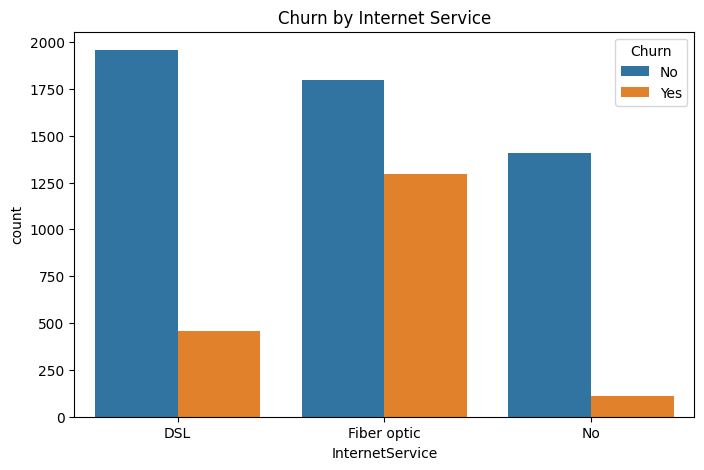

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Churn by Internet Service")
plt.show()

# PAYMENT METHOD ANALYSIS

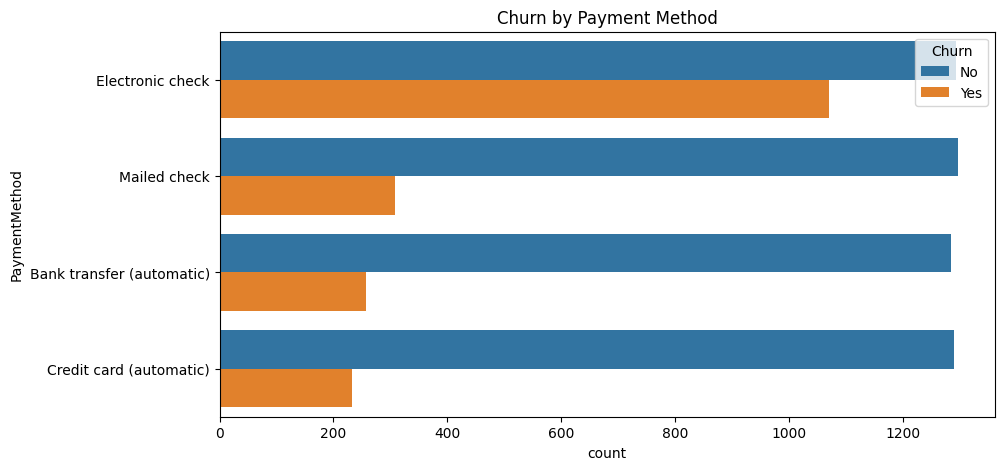

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="PaymentMethod",
    hue="Churn",
    data=df
)

plt.title("Churn by Payment Method")
plt.show()

# TENURE ANALYSIS

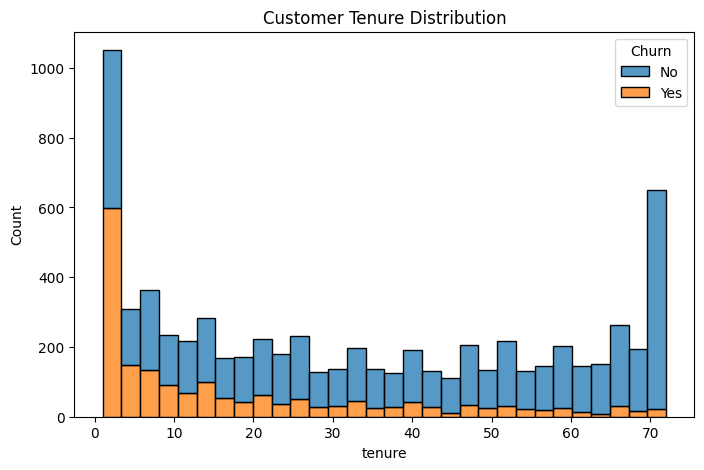

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    multiple="stack",
    bins=30
)

plt.title("Customer Tenure Distribution")
plt.show()

# MONTHLY CHARGES ANALYSIS

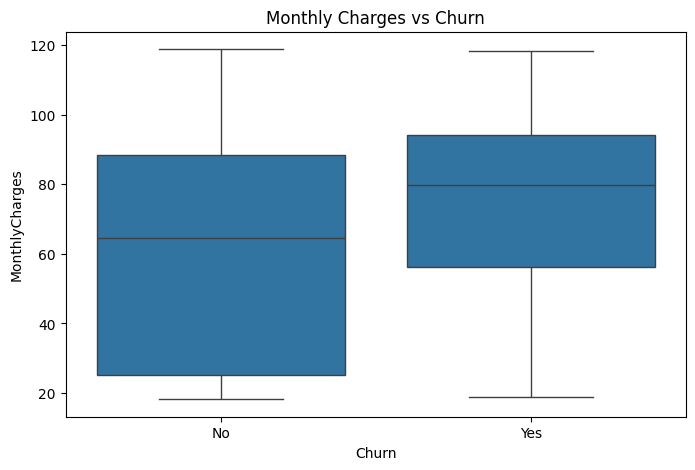

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.show()

# TOTAL CHARGES ANALYSIS

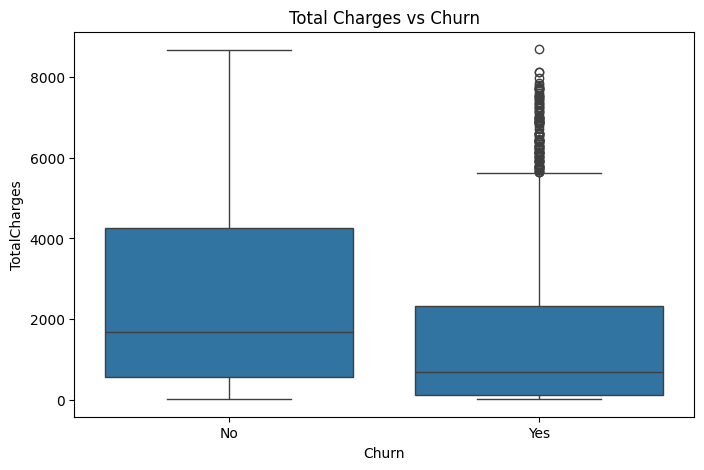

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="TotalCharges",
    data=df
)

plt.title("Total Charges vs Churn")
plt.show()

# CORRELATION ANALYSIS

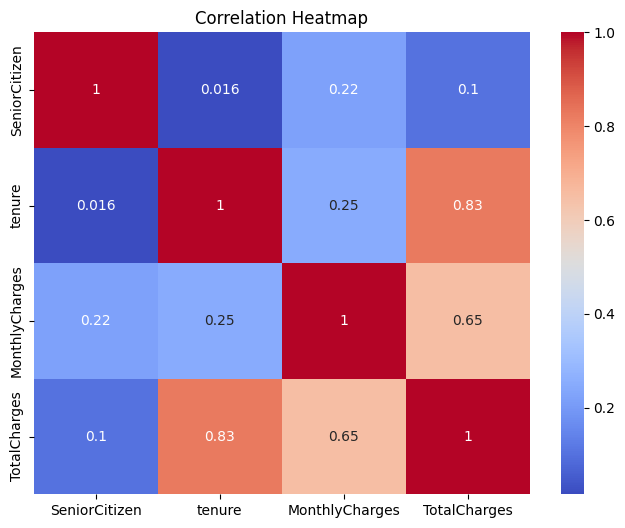

In [25]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

corr = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# Create Customer Segments

## Tenure Segmentation

In [27]:
#WHY TENURE? Because: long tenure = loyal customer , low tenure = risky customer! Tenure is one of the strongest churn indicators.

def tenure_group(tenure):

    if tenure <= 12:
        return "New Customer"

    elif tenure <= 36:
        return "Regular Customer"

    elif tenure <= 60:
        return "Loyal Customer"

    else:
        return "VIP Customer"


df["CustomerSegment"] = df["tenure"].apply(tenure_group)

In [28]:
df["CustomerSegment"].value_counts()

CustomerSegment
New Customer        2175
Regular Customer    1856
Loyal Customer      1594
VIP Customer        1407
Name: count, dtype: int64

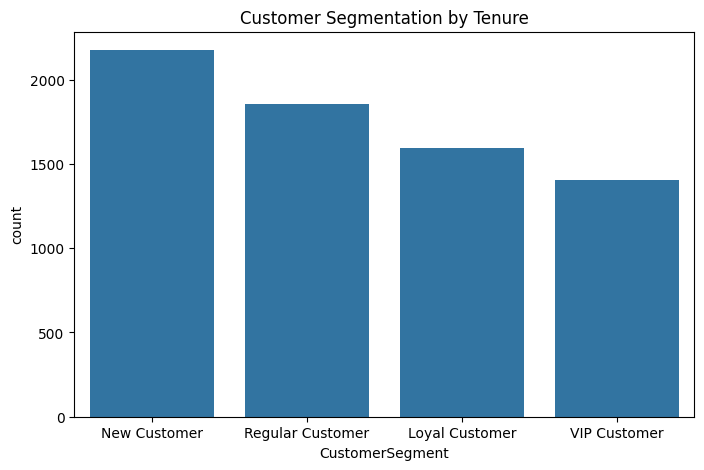

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    x="CustomerSegment",
    data=df
)

plt.title("Customer Segmentation by Tenure")
plt.show()

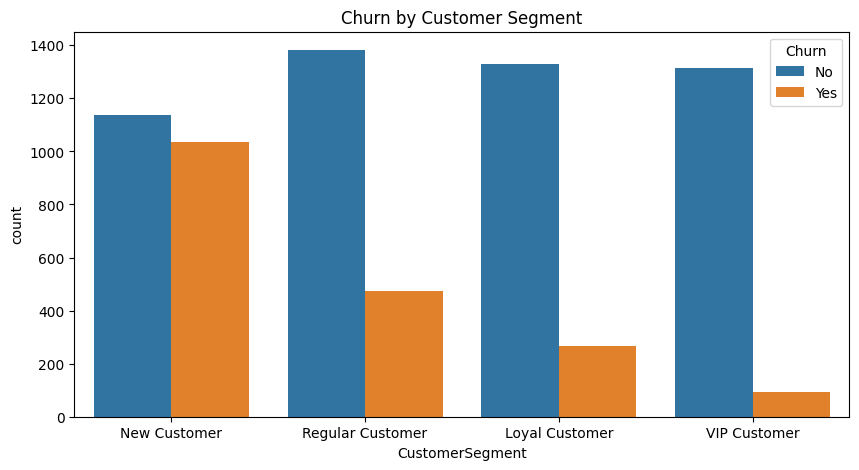

In [30]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="CustomerSegment",
    hue="Churn",
    data=df
)

plt.title("Churn by Customer Segment")
plt.show()

## HIGH VALUE CUSTOMER ANALYSIS

In [32]:
#Now identify customers generating high revenue.

df["HighValueCustomer"] = df["MonthlyCharges"] > 70 

# Creates: True → high-paying customers , False → normal customers

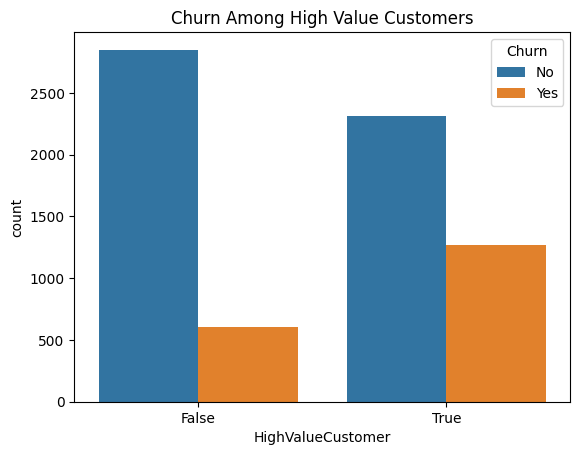

In [33]:
sns.countplot(
    x="HighValueCustomer",
    hue="Churn",
    data=df
)

plt.title("Churn Among High Value Customers")
plt.show()

# CHURN DRIVER IDENTIFICATION

## CHURN RATE BY CONTRACT TYPE

In [35]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


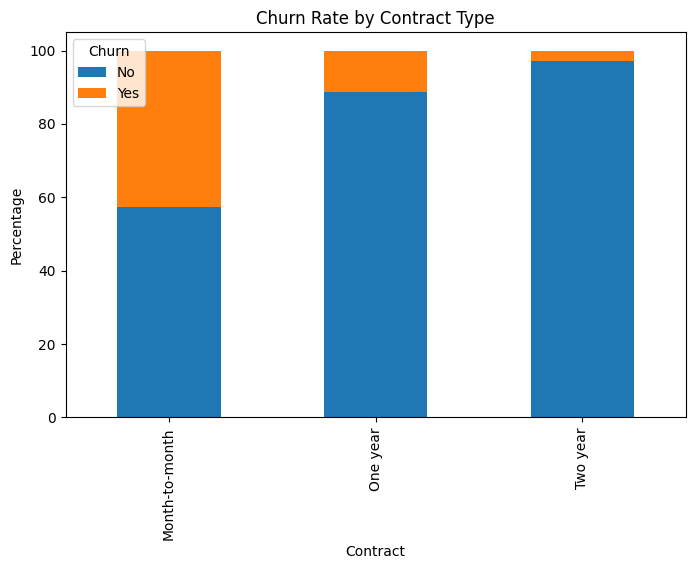

In [36]:
contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Churn Rate by Contract Type")
plt.ylabel("Percentage")
plt.show()

## CHURN RATE BY INTERNET SERVICE

In [37]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              81.001656  18.998344
Fiber optic      58.107235  41.892765
No               92.565789   7.434211


## TECH SUPPORT CHURN ANALYSIS

In [38]:
support_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

print(support_churn)

Churn                       No        Yes
TechSupport                              
No                   58.352535  41.647465
No internet service  92.565789   7.434211
Yes                  84.803922  15.196078


## ONLINE SECURITY ANALYSIS

In [39]:
security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

print(security_churn)

Churn                       No        Yes
OnlineSecurity                           
No                   58.221333  41.778667
No internet service  92.565789   7.434211
Yes                  85.359801  14.640199


## SENIOR CITIZEN ANALYSIS

In [40]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

print(senior_churn)

Churn                 No        Yes
SeniorCitizen                      
0              76.349745  23.650255
1              58.318739  41.681261


## MONTHLY CHARGES BUCKET ANALYSIS

### CREATE PRICE GROUPS

In [41]:
df["ChargeGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 35, 70, 120],
    labels=["Low", "Medium", "High"]
)

### ANALYZE CHURN BY PRICE GROUP

In [42]:
charge_churn = pd.crosstab(
    df["ChargeGroup"],
    df["Churn"],
    normalize="index"
) * 100

print(charge_churn)

Churn               No        Yes
ChargeGroup                      
Low          89.068826  10.931174
Medium       76.016260  23.983740
High         64.618822  35.381178


# COHORT ANALYSIS

## CREATE TENURE COHORTS

In [43]:
df["TenureCohort"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

In [44]:
df["TenureCohort"].value_counts()

TenureCohort
49-72 Months    2239
0-12 Months     2175
25-48 Months    1594
13-24 Months    1024
Name: count, dtype: int64

In [45]:
cohort_churn = pd.crosstab(
    df["TenureCohort"],
    df["Churn"],
    normalize="index"
) * 100

print(cohort_churn)

Churn                No        Yes
TenureCohort                      
0-12 Months   52.321839  47.678161
13-24 Months  71.289062  28.710938
25-48 Months  79.611041  20.388959
49-72 Months  90.486824   9.513176


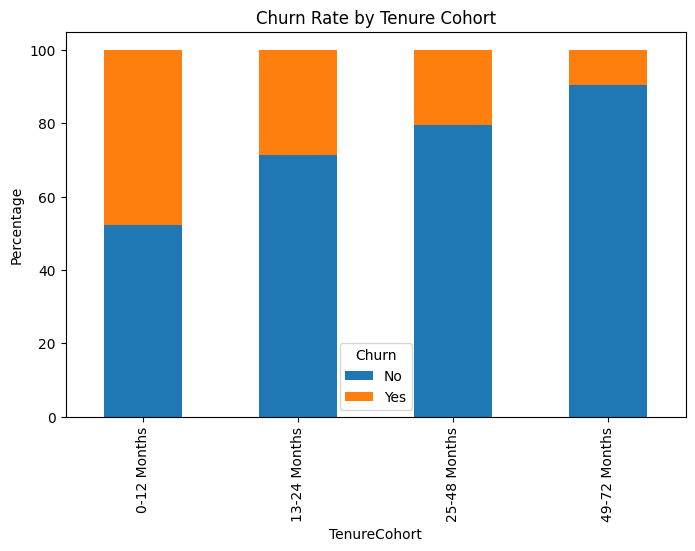

In [46]:
cohort_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Churn Rate by Tenure Cohort")
plt.ylabel("Percentage")
plt.show()

## RETENTION RATE

In [47]:
# FORMULA : Retention Rate=100−Churn Rate

cohort_retention = cohort_churn["No"]

print(cohort_retention)

TenureCohort
0-12 Months     52.321839
13-24 Months    71.289062
25-48 Months    79.611041
49-72 Months    90.486824
Name: No, dtype: float64


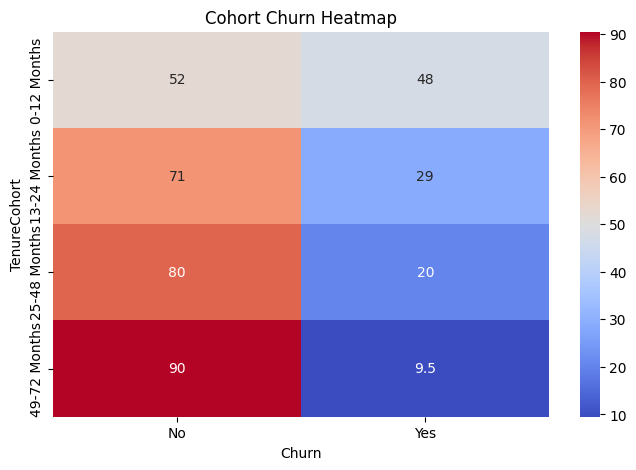

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.heatmap(
    cohort_churn,
    annot=True,
    cmap="coolwarm"
)

plt.title("Cohort Churn Heatmap")
plt.show()